# UD Typology Table — Demo

**Merged typological classification table for Universal Dependencies treebanks** from four sources:

- **WALS** Features 49A (case-marking) and 81A (word order)
- **Glottolog** language family classification
- **UD GitHub README** genre/modality metadata
- **HuggingFace-derived** Case feature proportions

This notebook loads a curated subset of the full 336-treebank table, computes coverage statistics,
validates cross-source consistency (Pearson r between WALS case ordinal and UD case proportion),
and visualizes the typological distributions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading

Load the curated mini dataset (40 diverse treebanks) from GitHub, with local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c3cfa4-sequential-dependency-distance-anti-corr/main/dataset_iter1_ud_typology_tab/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['metadata']['total_treebanks']} treebanks")
print(f"Sources: {data['metadata']['sources']}")

Loaded 40 treebanks
Sources: ['WALS CLDF (Features 49A, 81A)', 'Glottolog CLDF', 'UD GitHub READMEs', 'commul/universal_dependencies (HuggingFace)']


## Configuration

Display parameters for the analysis.

In [5]:
# --- Config ---
# Number of top language families to display in charts
TOP_N_FAMILIES = 10
# Number of sample rows to print in the table preview
PREVIEW_ROWS = 5
# Minimum pairs required for Pearson r calculation
MIN_PAIRS_FOR_CORRELATION = 3

## Parse Data into DataFrame

Extract the treebank examples from the loaded JSON and convert to a pandas DataFrame for analysis.

In [6]:
rows = data["datasets"][0]["examples"]
df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
df.head(PREVIEW_ROWS)[["metadata_treebank_id", "metadata_language_name", "metadata_wals_word_order_label",
                         "metadata_wals_case_label", "metadata_language_family", "metadata_modality"]]

DataFrame shape: (40, 32)


,metadata_treebank_id,metadata_language_name,metadata_wals_word_order_label,metadata_wals_case_label,metadata_language_family,metadata_modality
0,ab_abnc,Abkhaz,SOV,2 cases,Northwest Caucasian,written
1,apu_ufpa,Apurina,SVO,Exclusively borderline case-marking,Arawakan,written
2,cy_ccg,Welsh,VSO,No morphological case-marking,Indo-European,written
3,ckt_hse,Chukchi,No dominant order,10 or more cases,Chukotko-Kamchatkan,spoken
4,bg_btb,Bulgarian,SVO,No morphological case-marking,Indo-European,written


## Coverage Statistics

Compute how many treebanks have data from each source (WALS case, WALS word order, language family, modality).

In [7]:
n = len(df)
has_case = df["metadata_has_wals_case"].sum()
has_wo = df["metadata_has_wals_wordorder"].sum()
has_fam = df["metadata_has_family"].sum()
has_mod = df["metadata_has_modality"].sum()

print(f"Total treebanks: {n}")
print(f"WALS case (49A):       {has_case}/{n} ({100*has_case/n:.1f}%)")
print(f"WALS word order (81A): {has_wo}/{n} ({100*has_wo/n:.1f}%)")
print(f"Language family:       {has_fam}/{n} ({100*has_fam/n:.1f}%)")
print(f"Modality:              {has_mod}/{n} ({100*has_mod/n:.1f}%)")

Total treebanks: 40
WALS case (49A):       21/40 (52.5%)
WALS word order (81A): 25/40 (62.5%)
Language family:       39/40 (97.5%)
Modality:              38/40 (95.0%)


## Pearson r Validation

Cross-source consistency check: correlate the WALS case ordinal (49A category number) with the UD-derived case feature proportion. A positive correlation validates that the two independent sources agree on morphological case richness.

In [8]:
pairs = [
    (r["metadata_wals_case_category"], r["metadata_ud_case_proportion"])
    for r in rows
    if r["metadata_wals_case_category"] is not None and r["metadata_ud_case_proportion"] is not None
]

if len(pairs) >= MIN_PAIRS_FOR_CORRELATION:
    xs = np.array([p[0] for p in pairs])
    ys = np.array([p[1] for p in pairs])
    if np.std(xs) > 0 and np.std(ys) > 0:
        r_val = np.corrcoef(xs, ys)[0, 1]
        print(f"Pearson r (WALS case ordinal vs UD case proportion): {r_val:.3f} (n={len(pairs)})")
    else:
        print("Insufficient variance for correlation")
else:
    print(f"Not enough pairs for correlation (found {len(pairs)}, need {MIN_PAIRS_FOR_CORRELATION})")

Pearson r (WALS case ordinal vs UD case proportion): 0.472 (n=21)


## Visualization

Four-panel summary: (1) word order distribution, (2) case category distribution, (3) top language families, and (4) WALS case ordinal vs UD case proportion scatter.

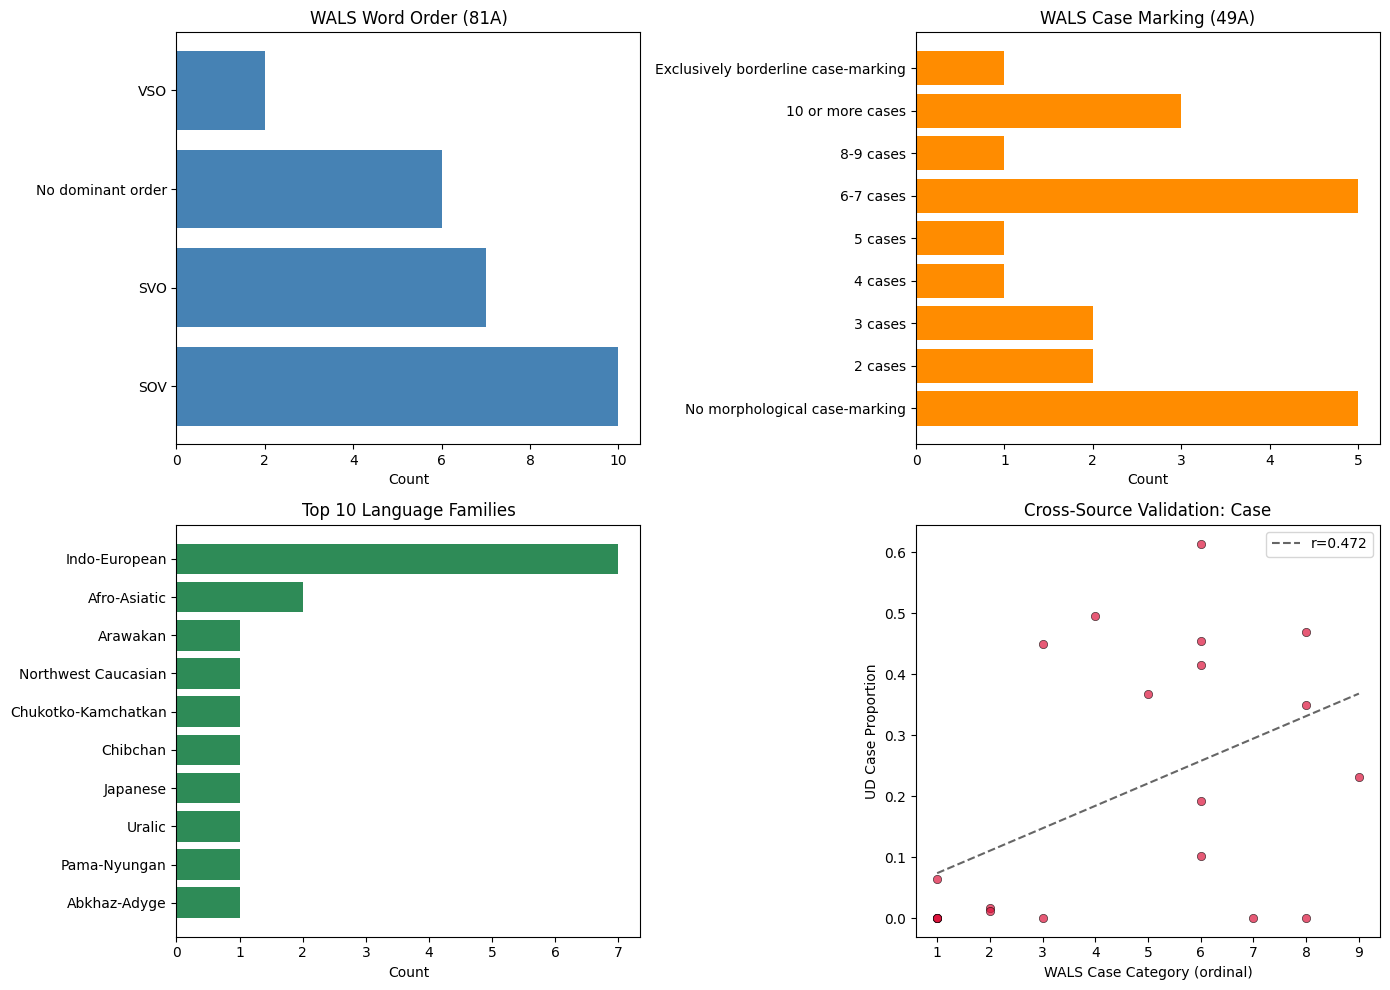

Saved typology_summary.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Word order distribution
wo_counts = df["metadata_wals_word_order_label"].dropna().value_counts()
axes[0, 0].barh(wo_counts.index, wo_counts.values, color="steelblue")
axes[0, 0].set_title("WALS Word Order (81A)")
axes[0, 0].set_xlabel("Count")

# 2. Case category distribution
case_counts = df["metadata_wals_case_category"].dropna().value_counts().sort_index()
case_labels = df.dropna(subset=["metadata_wals_case_category"]).drop_duplicates(
    subset=["metadata_wals_case_category"]).set_index("metadata_wals_case_category")["metadata_wals_case_label"]
bar_labels = [case_labels.get(c, str(int(c))) for c in case_counts.index]
axes[0, 1].barh(bar_labels, case_counts.values, color="darkorange")
axes[0, 1].set_title("WALS Case Marking (49A)")
axes[0, 1].set_xlabel("Count")

# 3. Top language families
fam_counts = df["metadata_language_family"].dropna().value_counts().head(TOP_N_FAMILIES)
axes[1, 0].barh(fam_counts.index[::-1], fam_counts.values[::-1], color="seagreen")
axes[1, 0].set_title(f"Top {TOP_N_FAMILIES} Language Families")
axes[1, 0].set_xlabel("Count")

# 4. WALS case vs UD case proportion scatter
if len(pairs) >= MIN_PAIRS_FOR_CORRELATION:
    xs_plot = np.array([p[0] for p in pairs])
    ys_plot = np.array([p[1] for p in pairs])
    axes[1, 1].scatter(xs_plot, ys_plot, alpha=0.7, edgecolors="k", linewidths=0.5, color="crimson")
    # Trend line
    if np.std(xs_plot) > 0:
        z = np.polyfit(xs_plot, ys_plot, 1)
        x_line = np.linspace(xs_plot.min(), xs_plot.max(), 50)
        axes[1, 1].plot(x_line, np.polyval(z, x_line), "k--", alpha=0.6, label=f"r={r_val:.3f}")
        axes[1, 1].legend()
    axes[1, 1].set_xlabel("WALS Case Category (ordinal)")
    axes[1, 1].set_ylabel("UD Case Proportion")
    axes[1, 1].set_title("Cross-Source Validation: Case")
else:
    axes[1, 1].text(0.5, 0.5, "Not enough data\nfor scatter plot",
                     ha="center", va="center", transform=axes[1, 1].transAxes)
    axes[1, 1].set_title("Cross-Source Validation: Case")

plt.tight_layout()
plt.savefig("typology_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved typology_summary.png")